In [1]:
%load_ext autoreload
%autoreload 2

import os
from os.path import join
import numpy as np
import matplotlib.pyplot as plt
import h5py
import logging

## CMASS visualize

In [2]:
def plot_rdz(rdz_input,shift=False):

    rdz = rdz_input.copy()

    if shift:

        ra = rdz[:, 0].copy()
        dec = rdz[:, 1].copy()
        ra[ra > 180] -= 360
        rdz[:, 0] = ra

    f, axs = plt.subplots(2, 1, figsize=(10, 10),
                        gridspec_kw={'height_ratios': [3, 1]})
    axs[0].plot(rdz[:, 0], rdz[:, 1], ',', ms=1, alpha=1)
    axs[0].set_title(f'samples {len(rdz)}')
    axs[1].hist(rdz[:, 2], bins=100, histtype='step', lw=2);

    return axs


def move_rdz(rdz_input):

    rdz = rdz_input.copy()

    ra = rdz[:, 0].copy()
    dec = rdz[:, 1].copy()
    ra[ra > 180] -= 360
    rdz[:, 0] = ra

    return rdz

def inverse_move_rdz(rdz_input):
    
    rdz = rdz_input.copy()

    ra = rdz[:, 0].copy()
    dec = rdz[:, 1].copy()
    ra[ra < 0] += 360
    rdz[:, 0] = ra

    return rdz

def plot_rdzs(rdz_inputs,labels = None,shift=False):

    f, axs = plt.subplots(2, 1, figsize=(10, 10),
                    gridspec_kw={'height_ratios': [3, 1]})
    
    if labels is None:
        labels = [f'samples{i}' for i in range(len(rdz_inputs))]

    for idx, rdz_input in enumerate(rdz_inputs):

        if shift:
            rdz = move_rdz(rdz_input)
        else:
            rdz = rdz_input.copy()

        axs[0].plot(rdz[:, 0], rdz[:, 1], ',', ms=1, alpha=1,label=f'{labels[idx]}: {len(rdz)} samples')
        axs[1].hist(rdz[:, 2], bins=100, histtype='step', lw=2,label=labels[idx]);
        #show legend 
        axs[0].legend()
        axs[1].legend()

    return axs

In [3]:
# load survey
import pandas as pd
from astropy.io import fits
def load_galaxies(fname, fields):
    with fits.open(fname) as hdul:
        gals = np.array([hdul[1].data[x] for x in fields]).T
        gals = pd.DataFrame(gals, columns=fields)    
    return gals

def load_cmass(fname):
    fields = ['RA','DEC','Z',
            'WEIGHT_SYSTOT','WEIGHT_NOZ','WEIGHT_CP']
    cmass = load_galaxies(fname, fields)
    crdz = cmass[['RA', 'DEC', 'Z']].values

    return crdz

In [4]:
from cmass.survey.tools import xyz_to_sky,sky_to_xyz
from astropy.cosmology import Planck18
from cmass.survey.selection import apply_mask

cosmo = Planck18

cmass_ngc_file = '/anvil/scratch/x-mho1/cmass-ili/obs/galaxy_DR12v5_CMASS_North.fits'  
cmass_sgc_file = '/anvil/scratch/x-mho1/cmass-ili/obs/galaxy_DR12v5_CMASS_South.fits'

cmass_ngc = load_cmass(cmass_ngc_file)
cmass_sgc = load_cmass(cmass_sgc_file)

cmass_ngc = apply_mask(cmass_ngc, '/anvil/scratch/x-mho1/cmass-ili', True, 0)
cmass_sgc = apply_mask(cmass_sgc, '/anvil/scratch/x-mho1/cmass-ili', False, 0)

ngc_xyz = sky_to_xyz(cmass_ngc, cosmo)
sgc_xyz = sky_to_xyz(cmass_sgc, cosmo)

[14:05:43-INFO] Running apply_mask...
[14:05:43-INFO] Applying redshift cut...
[14:05:43-INFO] Removed 39717/618806 galaxies
[14:05:43-INFO] Applying angular mask...
[14:05:44-INFO] Removed 6718/579089 galaxies
[14:05:44-INFO] Applying veto mask...
[14:06:02-INFO] Removed 0/572371 galaxies
[14:06:02-INFO] Finished apply_mask... (0m18s)
[14:06:02-INFO] Running apply_mask...
[14:06:02-INFO] Applying redshift cut...
[14:06:02-INFO] Removed 17626/230831 galaxies
[14:06:02-INFO] Applying angular mask...
[14:06:02-INFO] Removed 2737/213205 galaxies
[14:06:02-INFO] Applying veto mask...
[14:06:16-INFO] Removed 0/210468 galaxies
[14:06:16-INFO] Finished apply_mask... (0m14s)


In [6]:
cmass_ngc.shape

(572371, 3)

In [7]:
def rotate_3d(points, angle_rad, axis=2):
    """
    Rotate 3D points around a specified axis.
    
    Parameters:
    - points: (N, 3) array of 3D coordinates
    - angle_rad: rotation angle in radians
    - axis: axis to rotate around (0 = x, 1 = y, 2 = z)
    
    Returns:
    - rotated_points: (N, 3) array of rotated coordinates
    """
    if axis == 0:  # x-axis
        R = np.array([
            [1, 0, 0],
            [0, np.cos(angle_rad), -np.sin(angle_rad)],
            [0, np.sin(angle_rad),  np.cos(angle_rad)]
        ])
    elif axis == 1:  # y-axis
        R = np.array([
            [ np.cos(angle_rad), 0, np.sin(angle_rad)],
            [0, 1, 0],
            [-np.sin(angle_rad), 0, np.cos(angle_rad)]
        ])
    elif axis == 2:  # z-axis
        R = np.array([
            [np.cos(angle_rad), -np.sin(angle_rad), 0],
            [np.sin(angle_rad),  np.cos(angle_rad), 0],
            [0, 0, 1]
        ])
    else:
        raise ValueError("Axis must be 0 (x), 1 (y), or 2 (z)")

    return points @ R.T

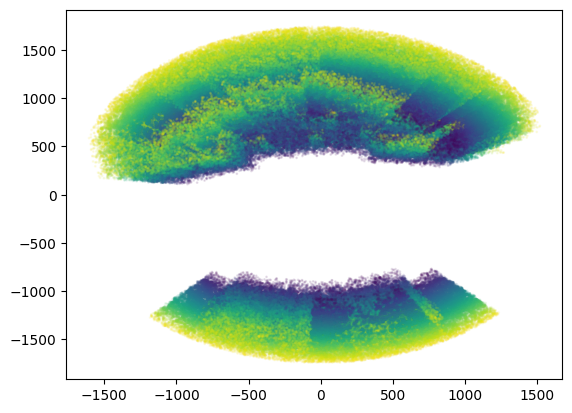

In [8]:
ngc_xyz_rotated = rotate_3d(ngc_xyz, -np.pi/2, axis=2)
sgc_xyz_rotated = rotate_3d(sgc_xyz, -np.pi/2, axis=2)
plt.scatter(ngc_xyz_rotated[:,0],ngc_xyz_rotated[:,1],s=1,alpha=0.1,c=cmass_ngc[:,-1])
plt.scatter(sgc_xyz_rotated[:,0],sgc_xyz_rotated[:,1],s=1,alpha=0.1,c=cmass_sgc[:,-1])
plt.show()


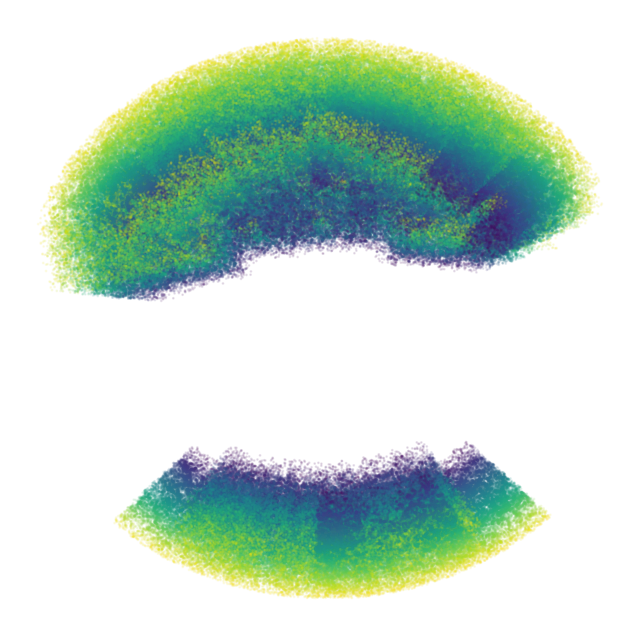

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))

sc1 = ax.scatter(ngc_xyz_rotated[:, 0], ngc_xyz_rotated[:, 1],
                 s=1, alpha=0.1, c=cmass_ngc[:, -1], cmap='viridis', rasterized=True, label='NGC')

sc2 = ax.scatter(sgc_xyz_rotated[:, 0], sgc_xyz_rotated[:, 1],
                 s=1, alpha=0.1, c=cmass_sgc[:, -1], cmap='viridis', rasterized=True, label='SGC')
ax.set_axis_off()

# Save as rasterized PDF
# plt.savefig("/home/x-csui/workspace/cmass/paper_figures/rotated_catalogs.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

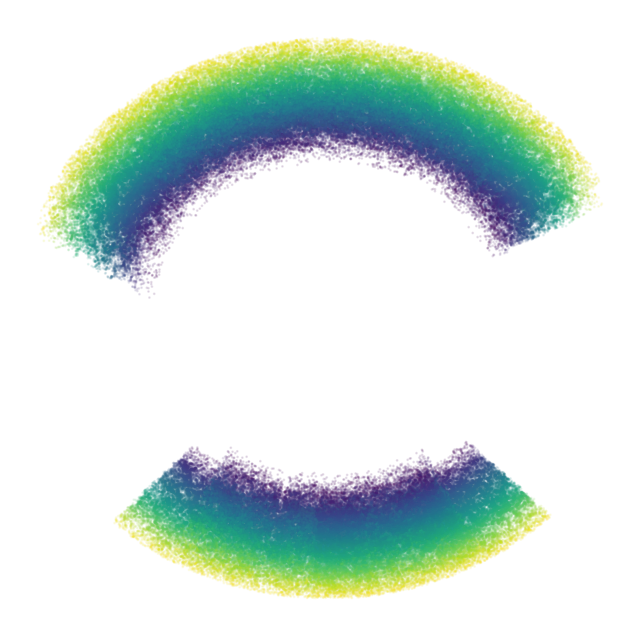

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))

ngc_xyz_rotated = rotate_3d(ngc_xyz, -np.pi/2, axis=2)
sgc_xyz_rotated = rotate_3d(sgc_xyz, -np.pi/2, axis=2)

slice_thickness = 500  # Thickness of the slice in the x-direction
x_slice_mask_ngc = (ngc_xyz_rotated[:, 2] > -slice_thickness) & (ngc_xyz_rotated[:, 2] < slice_thickness)
x_slice_mask_sgc = (sgc_xyz_rotated[:, 2] > -slice_thickness) & (sgc_xyz_rotated[:, 2] < slice_thickness)

sc1 = ax.scatter(ngc_xyz_rotated[x_slice_mask_ngc, 0], ngc_xyz_rotated[x_slice_mask_ngc, 1],
                 s=1, alpha=0.1, c=cmass_ngc[x_slice_mask_ngc, -1], cmap='viridis', rasterized=True, label='NGC')

sc2 = ax.scatter(sgc_xyz_rotated[x_slice_mask_sgc, 0], sgc_xyz_rotated[x_slice_mask_sgc, 1],
                 s=1, alpha=0.1, c=cmass_sgc[x_slice_mask_sgc, -1], cmap='viridis', rasterized=True, label='SGC')
ax.set_axis_off()

## Pipline Visualize

### ICs

In [ ]:
import numpy as np
import density_field_library as DFL

grid              = 128    #grid size
BoxSize           = 1000.0 #Mpc/h
seed              = 1      #value of the initial random seed
Rayleigh_sampling = 0      #whether sampling the Rayleigh distribution for modes amplitudes
threads           = 16      #number of openmp threads
verbose           = True   #whether to print some information

# read power spectrum; k and Pk have to be floats, not doubles
k, Pk = np.loadtxt('/home/x-csui/workspace/cmass/cmass_data/fastpm_1gpc/1/input_power_spectrum.txt', unpack=True)
k, Pk = k.astype(np.float32), Pk.astype(np.float32)

# generate a 2D Gaussian density field
df_2D = DFL.gaussian_field_2D(grid, k, Pk, Rayleigh_sampling, seed,
                              BoxSize, threads, verbose)

# generate a 3D Gaussian density field
df_3D = DFL.gaussian_field_3D(grid, k, Pk, Rayleigh_sampling, seed,
                              BoxSize, threads, verbose)

delta(k) field generated
time taken = 0.00088 seconds

delta(k) field generated
time taken = 0.12277 seconds



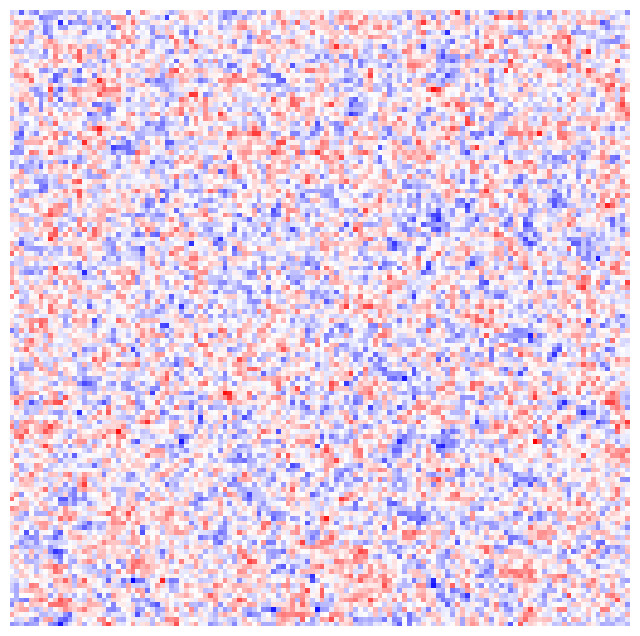

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolor(df_3D[0], cmap='bwr', vmax=5)
ax.set_axis_off()


### Fastpm

In [ ]:
nbody = h5py.File('/home/x-csui/workspace/cmass/cmass_data/fastpm_1gpc/0/nbody.h5', 'r')

In [ ]:
rho = nbody['0.666667']['rho']

In [ ]:
rho.shape

(128, 128, 128)

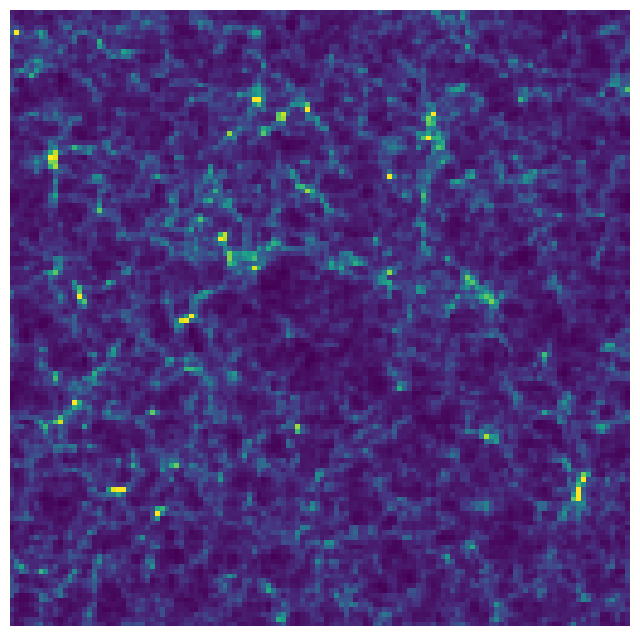

In [ ]:
fig,ax = plt.subplots(figsize=(8, 8))
im = ax.pcolor(rho[0], cmap='viridis',vmax = 5)
ax.set_axis_off()

In [ ]:
import pyvista as pv

def plot_3d_cube(field):

    plotter = pv.Plotter()

    eps = 1e-3

    grid = pv.ImageData()
    grid.dimensions = np.array(field.shape) #because dimensions are nodes, not cells
    grid.spacing = (1.+eps, 1.+eps, 1.+eps)  # voxel size
    grid.origin = (0, 0, 0)
    opacity = [1] * 10

    plotter.add_mesh(field, cmap='viridis',lighting=False, scalar_bar_args=None, clim=(0, 2))
    plotter.add_mesh(grid.outline(), color='white', line_width=2)


    plotter.remove_scalar_bar()
    plotter.show()

    return plotter


/anvil/projects/x-phy240043/x-csui/miniconda3/envs/cmass_ili/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


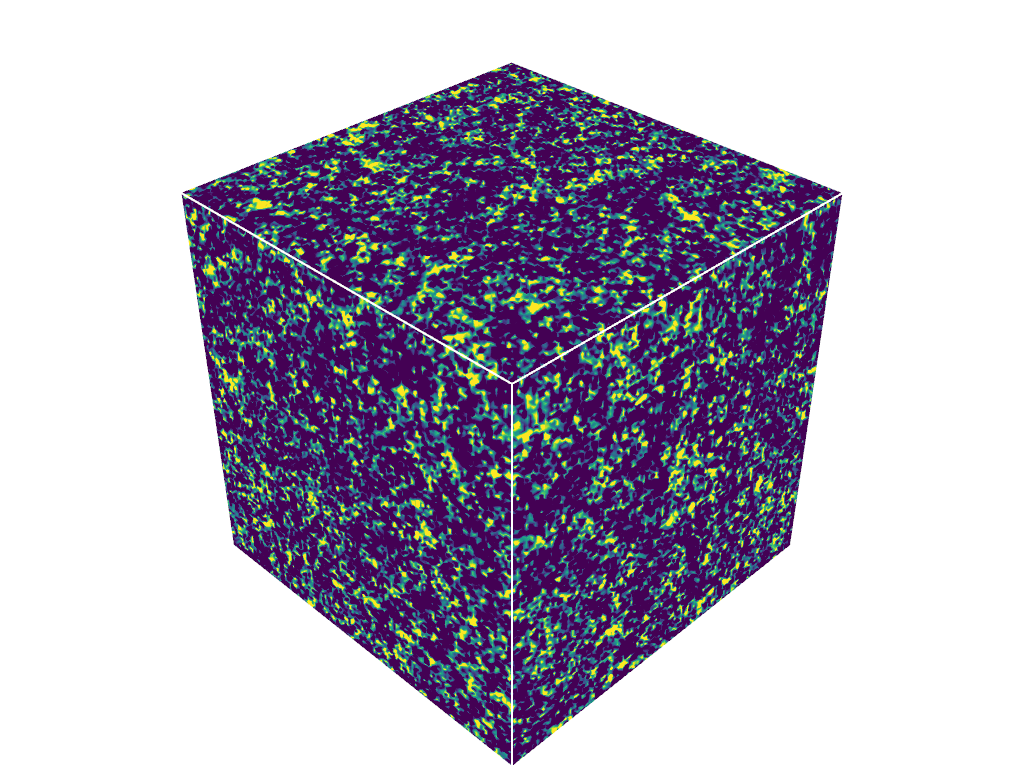

In [ ]:
plotter = plot_3d_cube(df_3D)

/anvil/projects/x-phy240043/x-csui/miniconda3/envs/cmass_ili/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


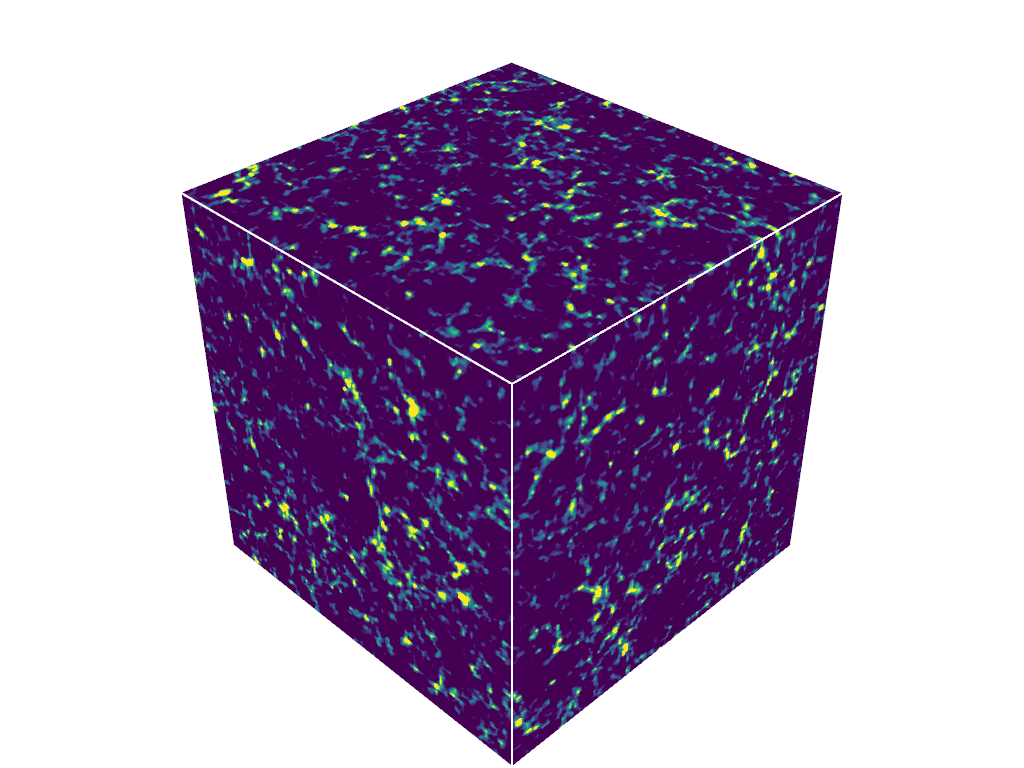

In [ ]:
plotter = plot_3d_cube(np.array(rho))

In [ ]:
plotter.screenshot("/home/x-csui/workspace/cmass/paper_figures/fastpm.png");

### halos

In [ ]:
halos = h5py.File('/home/x-csui/workspace/cmass/cmass_data/fastpm_1gpc/0/halos.h5', 'r')

In [ ]:
halos['0.666667'].keys()

<KeysViewHDF5 ['concentration', 'mass', 'pos', 'vel']>

In [ ]:
halos_pos = halos['0.666667']['pos'][:]

In [ ]:
halos_pos.shape

(118912, 3)

In [ ]:
def plot_3d_points(points,reference_field_shape=128,color='black', opacity=0.1,point_size = 5):
    plotter = pv.Plotter()
    plotter.add_points(points, render_points_as_spheres=True,lighting=False, point_size=point_size, color=color, opacity=opacity)

    eps = 1e-3

    grid = pv.ImageData()
    grid.dimensions = np.array([reference_field_shape]*3) #because dimensions are nodes, not cells
    grid.spacing = (8.+eps, 8.+eps, 8.+eps)  # voxel size
    grid.origin = (0, 0, 0)

    plotter.add_mesh(grid.outline(), color='white', line_width=2)


    plotter.show()

    return plotter

/anvil/projects/x-phy240043/x-csui/miniconda3/envs/cmass_ili/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


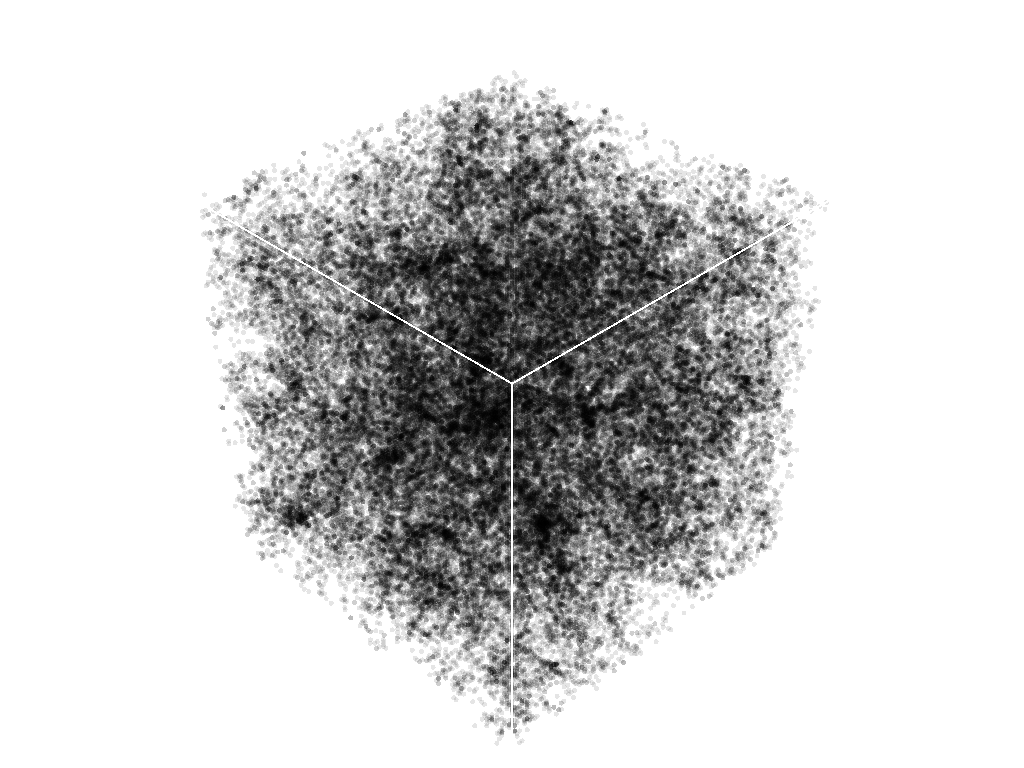

In [ ]:
plot_3d_points(np.array(halos_pos))

### galaxies

In [ ]:
gal = h5py.File('/home/x-csui/workspace/cmass/cmass_data/fastpm_1gpc/0/galaxies/hod00001.h5', 'r')

In [ ]:
gal['0.666667'].keys()

<KeysViewHDF5 ['gal_type', 'hostid', 'pos', 'vel']>

In [ ]:
gal_pos = gal['0.666667']['pos'][:]

/anvil/projects/x-phy240043/x-csui/miniconda3/envs/cmass_ili/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


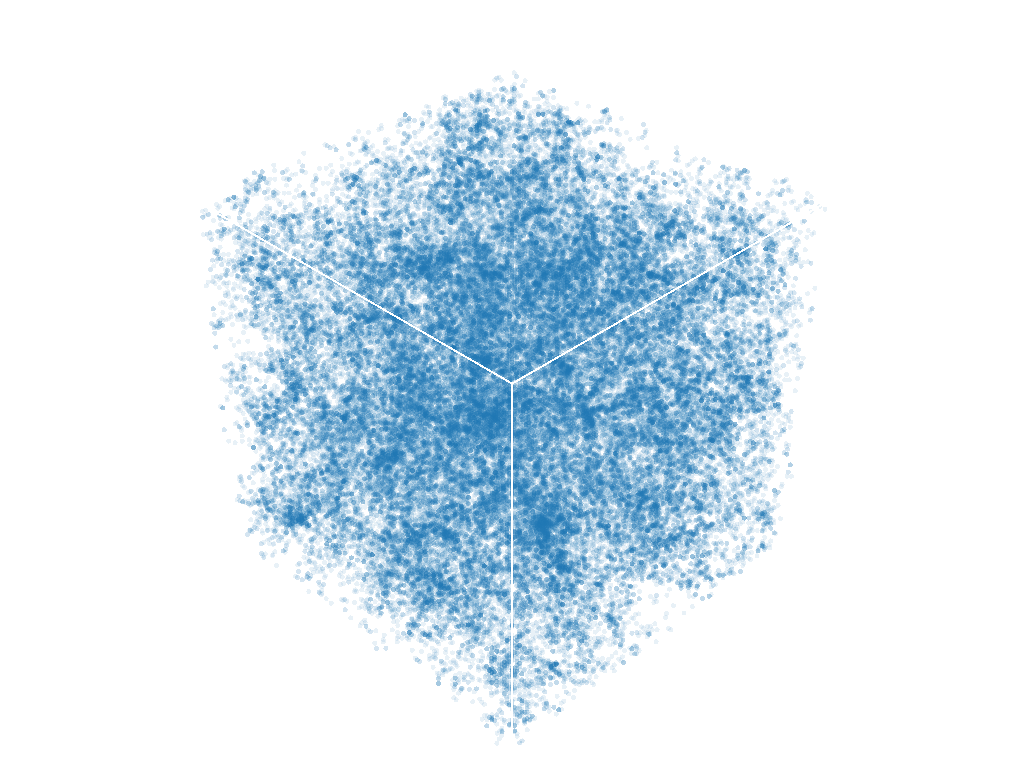

In [ ]:
plot_3d_points(np.array(gal_pos),color='tab:blue')

### lightcone

In [11]:
lightcone_gal_ngc = h5py.File('/home/x-csui/workspace/cmass/cmass-ili/mtnglike/1/ngc_lightcone/hod00011_aug00000.h5', 'r')
lightcone_gal_sgc = h5py.File('/home/x-csui/workspace/cmass/cmass-ili/abacuslike/1/sgc_lightcone/hod00011_aug00000.h5', 'r')

In [12]:
lc_ra_ngc, lc_dec_ngc, lc_z_ngc = lightcone_gal_ngc['ra'][:], lightcone_gal_ngc['dec'][:], lightcone_gal_ngc['z'][:]
lc_ra_sgc, lc_dec_sgc, lc_z_sgc = lightcone_gal_sgc['ra'][:], lightcone_gal_sgc['dec'][:], lightcone_gal_sgc['z'][:]

In [13]:
#combine rdz 
rdz_ngc = np.array([lc_ra_ngc, lc_dec_ngc, lc_z_ngc]).T
rdz_sgc = np.array([lc_ra_sgc, lc_dec_sgc, lc_z_sgc]).T

# rdz_ngc = apply_mask(rdz_ngc, '/anvil/scratch/x-mho1/cmass-ili', True, 0)
# rdz_sgc = apply_mask(rdz_sgc, '/anvil/scratch/x-mho1/cmass-ili', False, 0)

In [14]:
lc_xyz_ngc = sky_to_xyz(rdz_ngc, cosmo)
lc_xyz_sgc = sky_to_xyz(rdz_sgc, cosmo)

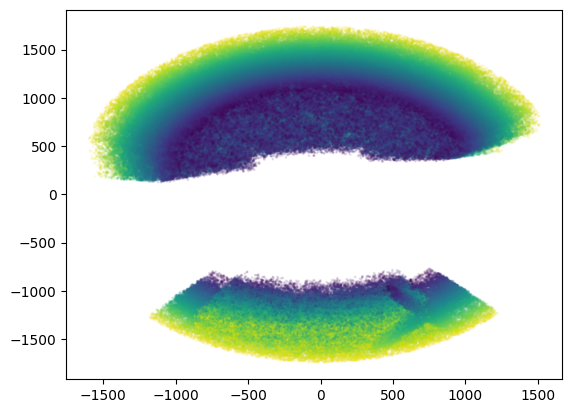

In [15]:
ngc_xyz_rotated = rotate_3d(lc_xyz_ngc, -np.pi/2, axis=2)
sgc_xyz_rotated = rotate_3d(lc_xyz_sgc, -np.pi/2, axis=2)
plt.scatter(ngc_xyz_rotated[:,0],ngc_xyz_rotated[:,1],s=1,alpha=0.1,c=rdz_ngc[:,-1])
plt.scatter(sgc_xyz_rotated[:,0],sgc_xyz_rotated[:,1],s=1,alpha=0.1,c=rdz_sgc[:,-1])
plt.show()


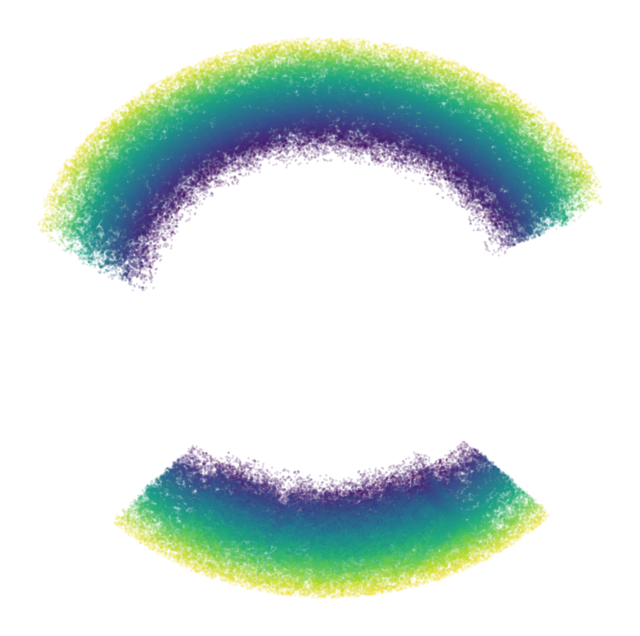

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))
ngc_xyz_rotated = rotate_3d(lc_xyz_ngc, -np.pi/2, axis=2)
sgc_xyz_rotated = rotate_3d(lc_xyz_sgc, -np.pi/2, axis=2)

slice_thickness = 500  # Thickness of the slice in the x-direction
x_slice_mask_ngc = (ngc_xyz_rotated[:, 2] > -slice_thickness) & (ngc_xyz_rotated[:, 2] < slice_thickness)
x_slice_mask_sgc = (sgc_xyz_rotated[:, 2] > -slice_thickness) & (sgc_xyz_rotated[:, 2] < slice_thickness)

sc1 = ax.scatter(ngc_xyz_rotated[x_slice_mask_ngc, 0], ngc_xyz_rotated[x_slice_mask_ngc, 1],
                 s=1, alpha=0.1, c=rdz_ngc[x_slice_mask_ngc,-1], cmap='viridis', rasterized=True, label='NGC')

sc2 = ax.scatter(sgc_xyz_rotated[x_slice_mask_sgc, 0], sgc_xyz_rotated[x_slice_mask_sgc, 1],
                 s=1, alpha=0.1, c=rdz_sgc[x_slice_mask_sgc, -1], cmap='viridis', rasterized=True, label='SGC')
ax.set_axis_off()